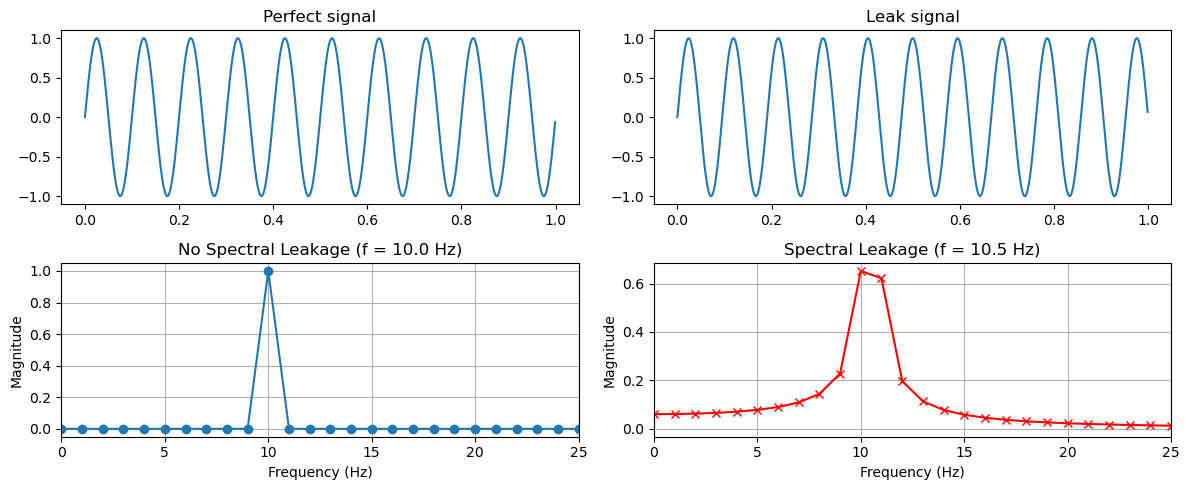

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
fs = 1000        # Sampling frequency (Hz)
T = 1.0          # Time duration of the window (seconds)
N = int(fs * T)  # Total number of samples
t = np.linspace(0, T, N, endpoint=False) # Time vector

# 2. Define Frequencies
# 10 Hz fits perfectly into a 1-second window (exactly 10 cycles)
f_perfect = 10.0 
# 10.5 Hz does NOT fit perfectly (10.5 cycles), causing a sudden jump at the edges
f_leak = 10.5

# 3. Generate Signals
signal_perfect = np.sin(2 * np.pi * f_perfect * t)
signal_leak = np.sin(2 * np.pi * f_leak * t)

# 4. Perform FFT (Normalize and take the first half of the spectrum)
fft_perfect = np.abs(np.fft.fft(signal_perfect)) / (N / 2)
fft_perfect = fft_perfect[:N//2]

fft_leak = np.abs(np.fft.fft(signal_leak)) / (N / 2)
fft_leak = fft_leak[:N//2]

# Frequency axis for plotting
freqs = np.fft.fftfreq(N, 1/fs)[:N//2]

# 5. Plot the Results
plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
plt.plot(t,signal_perfect)
plt.title('Perfect signal')

plt.subplot(2, 2, 2)
plt.plot(t,signal_leak)
plt.title('Leak signal')

# Plot 1: Perfect integer cycles (No Leakage)
plt.subplot(2, 2, 3)
plt.plot(freqs, fft_perfect, marker='o', linestyle='-')
plt.title("No Spectral Leakage (f = 10.0 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 25)
plt.grid(True)

# Plot 2: Non-integer cycles (Spectral Leakage)
plt.subplot(2, 2, 4)
plt.plot(freqs, fft_leak, marker='x', linestyle='-', color='red')
plt.title("Spectral Leakage (f = 10.5 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 25)
plt.grid(True)




plt.tight_layout()
plt.show()